In [1]:
#The spelled-out intro to neural networks and backpropagation: building micrograd
#https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=4

In [2]:
import micrograd
from graphviz import Digraph

In [3]:
###micrograd examples

from micrograd.engine import Value

a = Value(-4.0)
b = Value(2.0)
c = a + b
d = a * b + b**3
c += c + 1
c += 1 + c + (-a)
d += d * 2 + (b + a).relu()
d += 3 * d + (b - a).relu()
e = c - d
f = e**2
g = f / 2.0
g += 10.0 / f
print(f'{g.data:.4f}') # prints 24.7041, the outcome of this forward pass
g.backward()
print(f'{a.grad:.4f}') # prints 138.8338, i.e. the numerical value of dg/da
print(f'{b.grad:.4f}') # prints 645.5773, i.e. the numerical value of dg/db

24.7041
138.8338
645.5773


In [4]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:  
        try:
            if n.label is None:
                n.label = 'Unlabelled'
        except:
            n.label = 'Unlabelled'
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

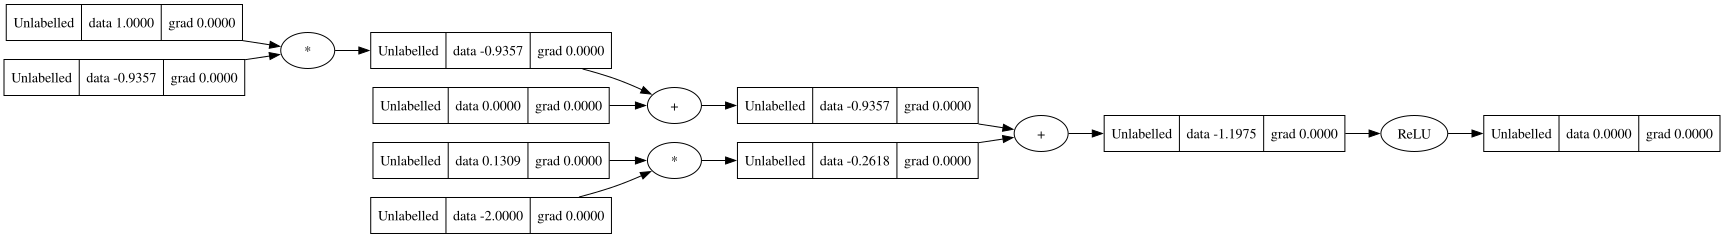

In [5]:
from micrograd import nn
n = nn.Neuron(2)
x = [Value(1.0), Value(-2.0)]
y = n(x)
dot = draw_dot(y)
dot

In [6]:
### the demo ipynb - micrograd is the bare minimum code.


In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [8]:
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

In [9]:

np.random.seed(1337)
random.seed(1337)

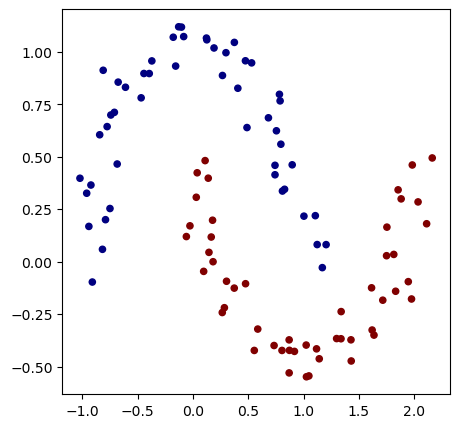

In [10]:
# make up a dataset

from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1 # make y be -1 or 1
# visualize in 2D
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')

In [11]:
# initialize a model 
model = MLP(2, [16, 16, 1]) # 2-layer neural network
print(model)
print("number of parameters", len(model.parameters()))

MLP of [Layer of [ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2), ReLUNeuron(2)], Layer of [ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16), ReLUNeuron(16)], Layer of [LinearNeuron(16)]]
number of parameters 337


In [12]:
# loss function
def loss(batch_size=None):
    
    # inline DataLoader :)
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # forward the model to get scores
    scores = list(map(model, inputs))
    
    # svm "max-margin" loss
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)

total_loss, acc = loss()
print(total_loss, acc)

Value(data=0.8958441028683222, grad=0) 0.5


In [13]:
# optimization
for k in range(100):
    
    # forward
    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*k/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
    
    if k % 1 == 0:
        print(f"step {k} loss {total_loss.data}, accuracy {acc*100}%")

step 0 loss 0.8958441028683222, accuracy 50.0%
step 1 loss 1.7235905336972022, accuracy 81.0%
step 2 loss 0.7429006313851131, accuracy 77.0%
step 3 loss 0.7705641260584201, accuracy 82.0%
step 4 loss 0.3692793385976537, accuracy 84.0%
step 5 loss 0.31354548191852194, accuracy 86.0%
step 6 loss 0.2814234349772435, accuracy 89.0%
step 7 loss 0.26888733313983904, accuracy 91.0%
step 8 loss 0.2567147286057417, accuracy 91.0%
step 9 loss 0.2704862551637922, accuracy 91.0%
step 10 loss 0.24507023853658041, accuracy 91.0%
step 11 loss 0.25099055297915035, accuracy 92.0%
step 12 loss 0.21560951851922952, accuracy 91.0%
step 13 loss 0.23090378446402726, accuracy 93.0%
step 14 loss 0.20152151227899445, accuracy 92.0%
step 15 loss 0.22574506279282228, accuracy 93.0%
step 16 loss 0.19447987596204114, accuracy 92.0%
step 17 loss 0.21089496199246355, accuracy 93.0%
step 18 loss 0.15983077356303607, accuracy 94.0%
step 19 loss 0.18453748746883916, accuracy 93.0%
step 20 loss 0.18977522856087653, accu

(-1.548639298268643, 1.951360701731357)

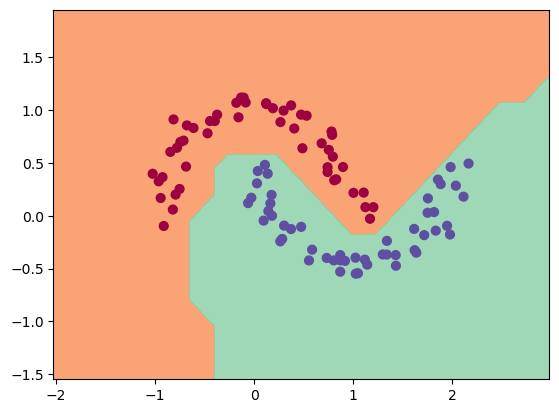

In [14]:
# visualize decision boundary

h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())

In [15]:
#### live coding in the lecture from here. (above is from the demos on the github. 

##whats a derivatibe..?

In [16]:
import math
import numpy as np 
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
def f(x):
    return 3*x**2 - 4*x + 5

In [18]:
f(3.0)

20.0

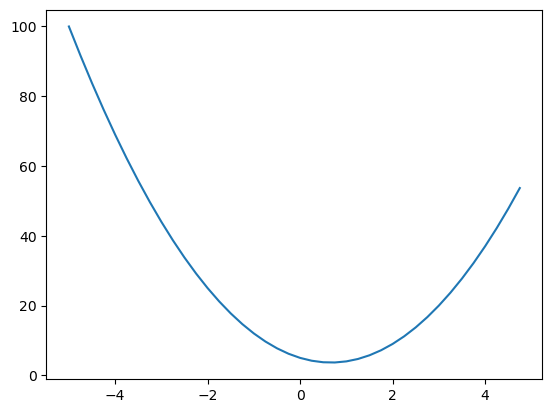

In [19]:
xs = np.arange(-5,5, 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [20]:
h = 0.000001
x = 2/3.0
(f(x+h) - f(x))/(x+h-x)
#small h tends to answer but careful of floating point arithmetic

2.9993785232410738e-06

In [21]:
##simple so far, increase the complexity. 
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)


4.0


In [22]:
h = 0.0001

# inputs
a = 2.90
b = -3.0
c = 10.0
d1 = a*b+c
a += h
d2 = a*b +c

print(f"d1 {d1}, d2 {d2}, slope {(d2-d1)/h}")


d1 1.3000000000000007, d2 1.2996999999999996, slope -3.000000000010772


In [23]:
##principle is the same for NNs but with a large expression ... a value object in python.

In [88]:
class Value:

    def __init__(self,data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None ## chain rule for back propgation..
        self._prev = set(_children)
        self._op = _op 
        self.label = label
        
    def __repr__(self): #redefines print (you'd get the addresses otherwise)
        return f"Value(data={self.data})"

    def __add__(self, other): #redefines addition
        other = other if isinstance(other,Value) else Value(other) #fix addition by wrapping numbers in Value class
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad    
        out._backward = _backward
        
        return out
    #e.g. #(a.__mul__(b)).__add__(c) is a x b + c ##(note that this has 2 operations so split it up or it will be mislablled.

    def __mul__(self, other): # multiply
        other = other if isinstance(other,Value) else Value(other) #fix multiply
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += (other * self.data**(other-1)) * out.grad
        out._backward = _backward

        return out
    
    def __rmul__(self, other): #other * self e.g. 2.__mul__(a) error solved by swapping.
        return self * other

    def __truediv__(self, other): #self/other #rather than division do a/b = a * 1/b = a * b **-1, ### and needed to define ** (pow)
        return self * other ** -1

    def __neg__(self): # -1 * self
        return self * -1
    
    def __sub__(self, other): # self + (neg other)
        return self + (-other)
        
    def __radd__(self, other): # other + self
        return self + other
        
    def exp(self): ###could do this but actually we just care about derivatives so simpler to just do tanh. ### then added it later...
        x = self.data
        t = math.exp(x)
        out = Value(t, (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out
        
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




In [87]:
a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f; L.label = 'L'
L

Value(data=-8.0)

In [25]:
d._prev

{Value(data=-6.0), Value(data=10)}

In [26]:
d._op 

'+'

In [27]:
#added _preb and _op so the result shows where it came from and by what expression.

In [28]:

### he then copies a simpler version of the  draw_dot(d) (without the d.grad attribute)
##ive added try assert to the template one.


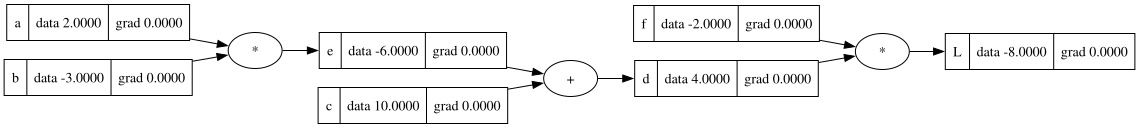

In [29]:
draw_dot(L)

In [30]:
### so how do we backwards propogate with gradients?
L.grad = 1.0

In [31]:
def lol():
    """
    this function stops messing with the global scope.
    """
    h = 0.0001
    
    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10, label = 'c')
    #c = Value(10+h, label = 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    #b.data += h
    #d.data += h
    #f = Value(-2.0+h, label='f') #check certain nodes by doing the f(x+h) inline at that variable
    f = Value(-2.0, label='f')
    L = d*f; L.label = 'L'
    #L2 = L.data + h
    L.data += h
    L2 = L.data 
    print((L2-L1)/h)

lol()

0.9999999999976694


In [32]:
f.grad = 4.0 #the value of d
d.grad = -2.0 #the value of f

In [33]:
a.grad = (-2.0 * -3.0)
b.grad = (-2.0 * 2.0)

In [34]:
# Moving to a more complicated example..

In [35]:
##CS231n neuron ## https://cs231n.github.io/neural-networks-1/

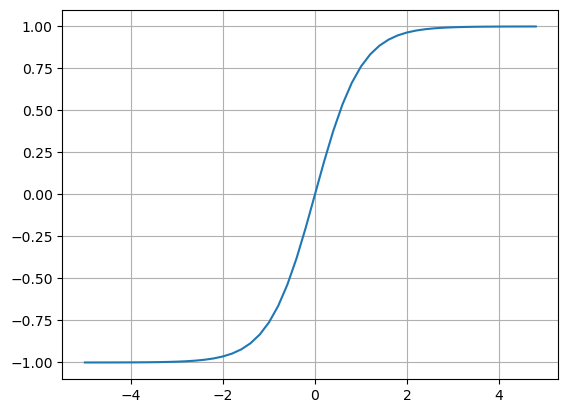

In [36]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [37]:
#inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights w1, w2 (synaptic strength)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron 
b = Value(6.8814, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh() #need to implement exponents. def exp() ^^^

In [38]:
#1 - o.data**2
#0.6603640386116149

In [39]:
# o = tanh(n)
# do.dn = 1- o**2

In [40]:
o.grad = 1.0 #still need to initialise to zero
o._backward()

n._backward() #n.grad = 0.5

x1w1x2w2._backward() #x1w1x2w2.grad = 0.5
b._backward() #b.grad = 0.5
x1w1._backward() #x1w1.grad = 0.5
x2w2._backward() #x2w2.grad = 0.5 #+ nodes just let the gradient simply flow.

x1._backward() #x1.grad = x1.data * x1w1.grad
w1._backward() #w1.grad = w1.data * x1w1.grad
x2._backward() #x2.grad = w2.data * x2w2.grad
w2._backward() #w2.grad = x2.data * x2w2.grad
#dervative is always the influence on the output, hence 0 dy/dx from zero multiples..

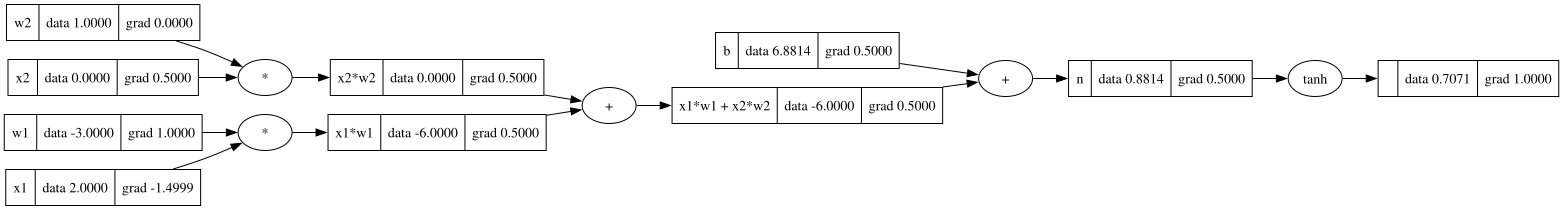

In [41]:
draw_dot(o)

In [42]:
###now need a way to do the chain rule back propogation automatically...
#def _backward
#but still calling data._backward() manually. we need to not call _backward until its dependencies are decided.
#this is solved by topological sort. 

In [43]:
o.grad = 1.0

topo = []
visited = set()
def build_topo(v):
    """
    adds v to list iff its children are in the list
    """
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward()

topo

[Value(data=6.8814),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=-6.0),
 Value(data=0.8814000000000002),
 Value(data=0.7071199874301227)]

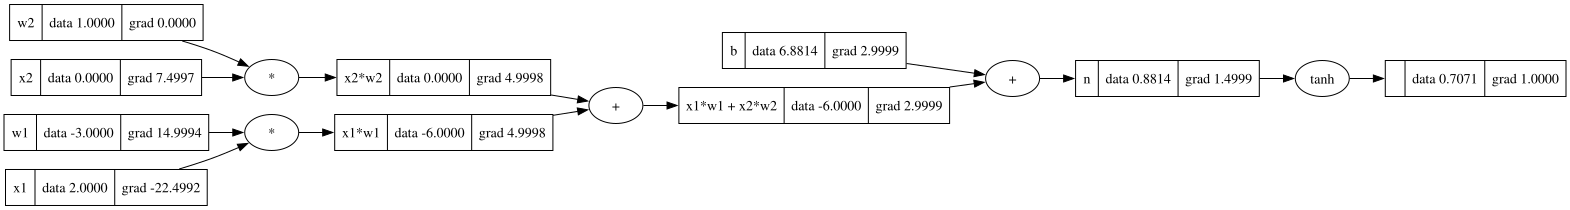

In [44]:
o.backward()
draw_dot(o)

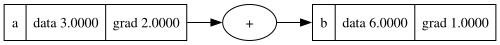

In [45]:
### but theres a bug..  db/da = 2 here, while sum nodes mave a default max of 1, not an issue if each variable only used once.

a = Value(3.0, label = 'a')
b = a + a ; b.label ='b'
b.backward()
draw_dot(b)

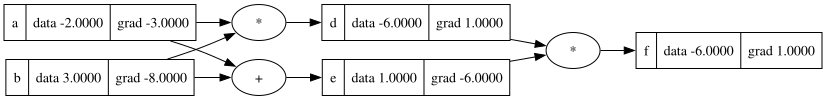

In [46]:
a = Value(-2.0, label = 'a')
b = Value(3.0, label = 'b')
d = a*b ; d.label = 'd'
e = a+b ; e.label = 'e'
f = d*e ; f.label = 'f'

f.backward()
draw_dot(f)


In [47]:
###### Then he cleans up a bit but I'm going o keep it here.

In [48]:
#fixed addition
a+1


Value(data=-1.0)

In [49]:
# and multiply
a*2

Value(data=-4.0)

In [50]:
# 2.__mul__(a) # but 2 * a is still 
2 * a ## python auto check __rmul__ if the multiplication doesn't work. 

Value(data=-4.0)

In [51]:
#adding exp and division, subtraction etc.
a - 2

Value(data=-4.0)

In [52]:
a/2

Value(data=-1.0)

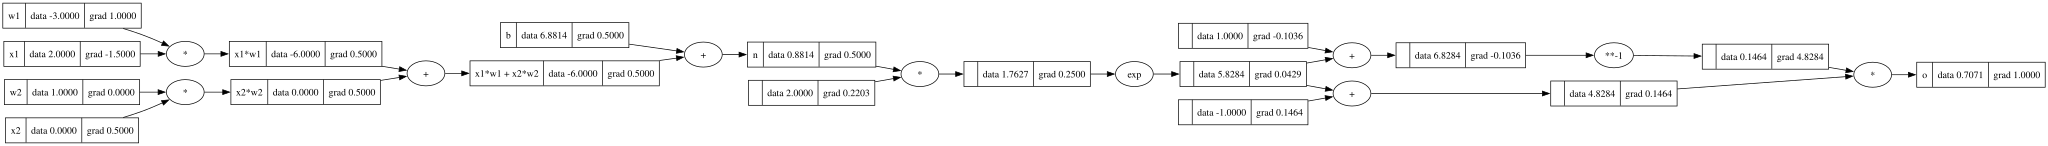

In [53]:
#inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
#weights w1, w2 (synaptic strength)
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron 
b = Value(6.8813735870195432, label='b')
# x1w1 + x2w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp()
o = (e-1)/(e+1)

o.label = 'o'
o.backward()
draw_dot(o)

In [54]:
#notice the machinery works for the added steps that contribute to tanh.

# you can decide the size of step as long as you can calculate the grad for back propogating

In [55]:
## now with pytorch.

import torch

x1 = torch.Tensor([2.0]).double() ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double() ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double() ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double() ; w2.requires_grad = True
b = torch.Tensor([6.88137]).double() ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item(),'\n---')
o.backward()

print(f"x2 {x2.grad.item()}")
print(f"w2 {w2.grad.item()}")
print(f"x1 {x1.grad.item()}")
print(f"w1 {w1.grad.item()}")

0.7071050214706146 
---
x2 0.5000024886110417
w2 0.0
x1 -1.500007465833125
w1 1.0000049772220834


In [56]:
## usually you work with a tensor with more elements
torch.Tensor([[1,2,3],[4,5,6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [57]:
torch.Tensor([[1,2,3],[4,5,6]]).dtype 

torch.float32

In [58]:
torch.Tensor([[1,2,3],[4,5,6]]).double().dtype #python uses doubles. 

torch.float64

In [59]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

In [60]:
##micrograd is a special case of pytorch where all the tensors are 1d single element doubles. 

In [166]:

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        #print(list(zip(self.w,x)))
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        """
        convenience parameters
        """
        return self.w + [self.b]


x = [2.0,3.0]
n = Neuron(2)
n(x) # how to run call , turns the class instance into a callable function

Value(data=0.9888152821607522)

In [167]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        """
        convenience parameters
        """
        return [p for neuron in self.neurons for p in neuron.parameters()]

n = Layer (2,3)
n(x)

[Value(data=0.9994050160164224),
 Value(data=0.472481979110129),
 Value(data=0.3185347477769929)]

In [168]:
class MLP:
    """
    multilayer perceptron .. percetron 
    """
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i  in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x

    def parameters(self):
        """
        convenience parameters
        """
        return [p for layer in self.layers for p in layer.parameters()]

x = [2.0,3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)   

Value(data=-0.8353945780999094)

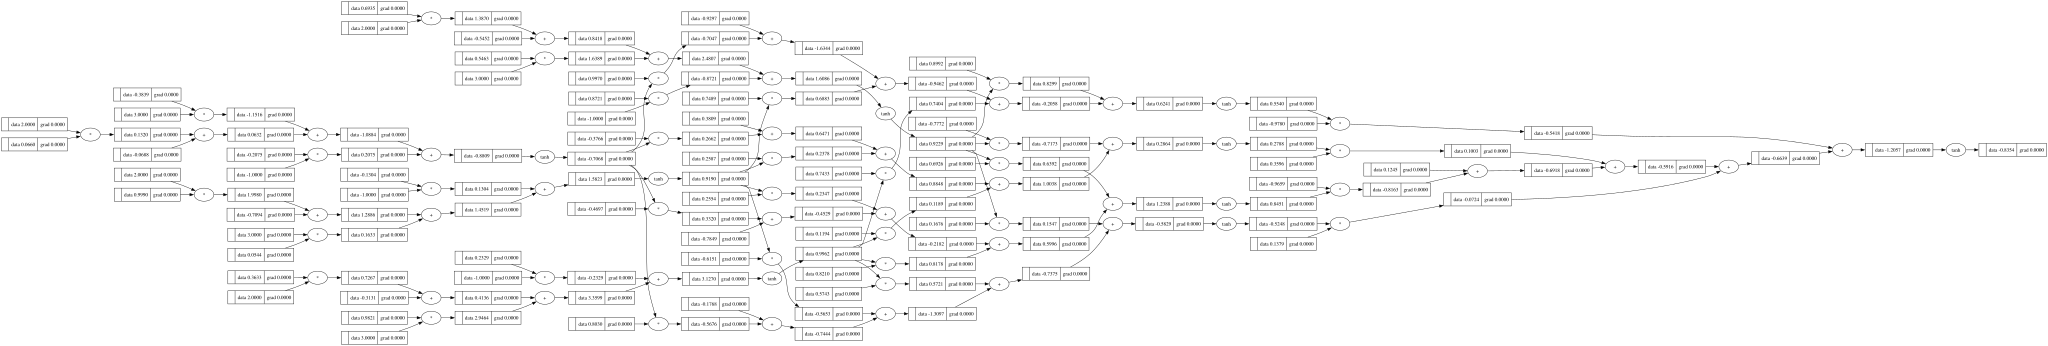

In [169]:
draw_dot(n(x))

In [170]:
## supervised data
xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys = [1.0,-1.0,-1.0,1.0] #desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=-0.8353945780999094),
 Value(data=-0.49638175074030166),
 Value(data=-0.08818558034187902),
 Value(data=0.711230255668507)]

In [171]:
# how far are the predictions from the truth
[(yout-ygt)**2 for ygt, yout in zip(ys, ypred)]

[Value(data=3.368673257318544),
 Value(data=0.25363134098740364),
 Value(data=0.8314055358964759),
 Value(data=0.08338796524127587)]

In [172]:
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss #need to minimise the loss.

Value(data=4.537098099443699)

In [173]:
loss.backward()

In [174]:
n.layers[0].neurons[0].w[0].data

0.06601284235357685

In [175]:
n.layers[0].neurons[0].w[0].grad #does it change the loss positively or negatively?

0.28384175840700937

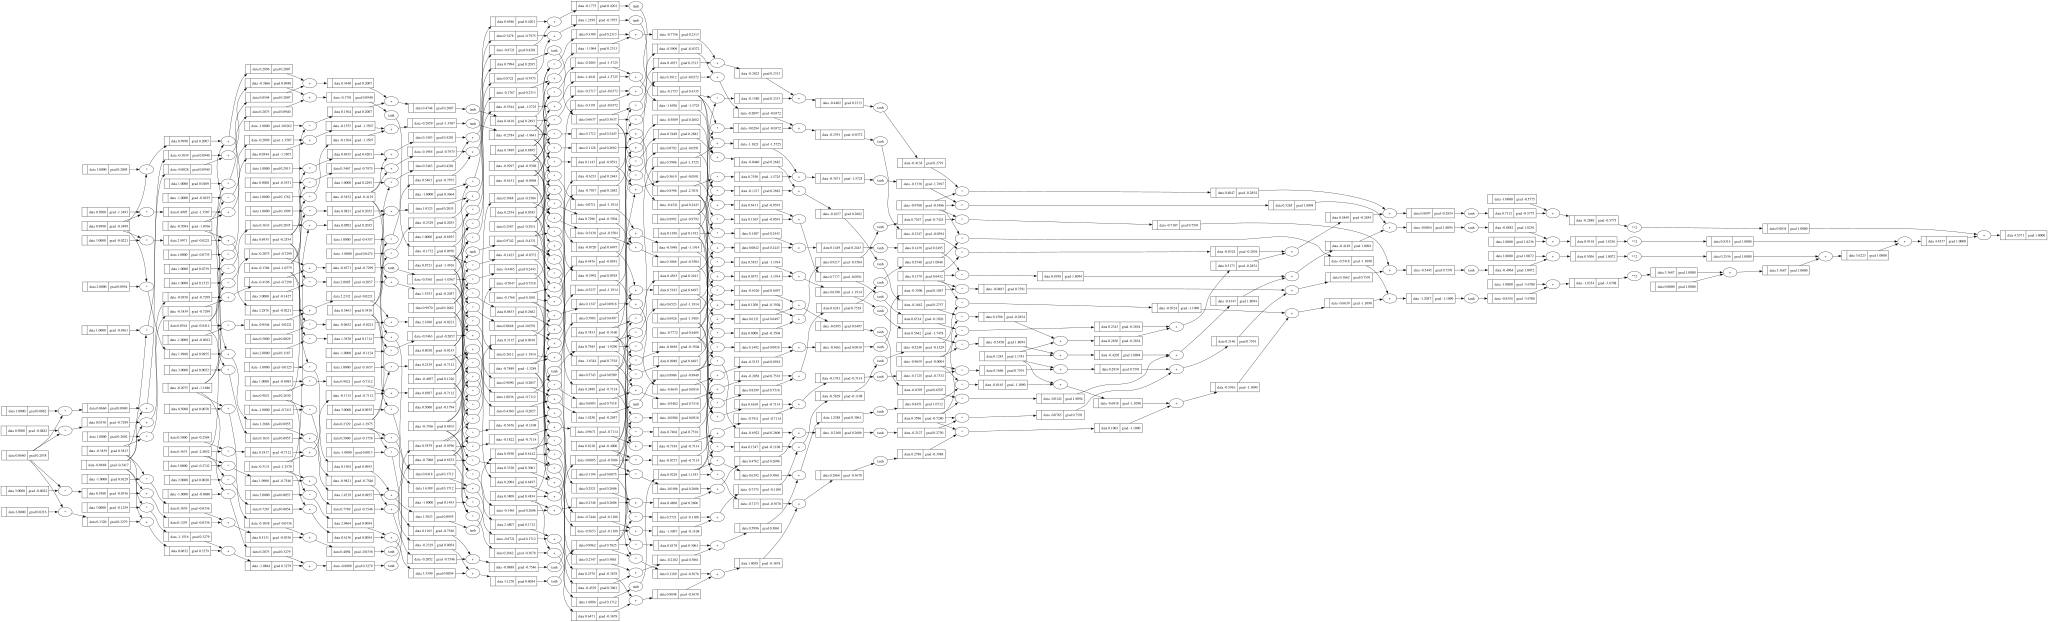

In [176]:
draw_dot(loss)

In [177]:
#about to do convenience code to operate on the NN collectively.

len(n.parameters())

41

In [178]:
n.parameters()

[Value(data=0.06601284235357685),
 Value(data=-0.3838644199658541),
 Value(data=-0.20750162690641338),
 Value(data=-0.06878655269562106),
 Value(data=0.9990204506000446),
 Value(data=0.05443661535838262),
 Value(data=-0.13042014790341172),
 Value(data=-0.7094315388803791),
 Value(data=0.36333814426135036),
 Value(data=0.9821213777355291),
 Value(data=0.23294598445363213),
 Value(data=-0.31312344810383963),
 Value(data=0.6934921871786166),
 Value(data=0.5462975138636161),
 Value(data=0.8720869607579878),
 Value(data=-0.54522579358834),
 Value(data=-0.4697111074697169),
 Value(data=0.25535768931192115),
 Value(data=0.8209590199415573),
 Value(data=0.6925966491002429),
 Value(data=-0.7849187777010802),
 Value(data=-0.3766144950914978),
 Value(data=0.25874994745217084),
 Value(data=0.11937959374492468),
 Value(data=-0.7772251335674811),
 Value(data=0.3808516815262748),
 Value(data=0.803017276975381),
 Value(data=-0.6150944306595045),
 Value(data=0.5743288164728753),
 Value(data=0.167574922

In [179]:
#nudge
for p in n.parameters():
    p.data += -0.01 * p.grad #alter each parameter in the direction that decreases loss

In [180]:
print(n.layers[0].neurons[0].w[0].data,',',  n.layers[0].neurons[0].w[0].grad)

0.06317442476950676 , 0.28384175840700937


In [181]:
n.layers[0].neurons[0].w[0].grad

0.28384175840700937

In [182]:
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss #need to minimise the loss.

Value(data=4.537098099443699)

In [183]:
####sign error in my loss change..  ###need to zero the gradients first
for p in n.parameters():
    p.grad = 0.0

# forward pass
ypred = [n(x) for x in xs]

# calculate loss
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

# backward pass
loss.backward() ##missed this bit down below.

# nudge
for p in n.parameters():
    p.data += -0.01 * p.grad

In [184]:
print(n.layers[0].neurons[2].w[0].data,',',  n.layers[0].neurons[2].w[0].grad)

0.4036591548466598 , -1.6268834841953046


In [185]:
###checking gradient likelihood

xs = [
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0],
]
ys = [1.0,-1.0,-1.0,1.0] #desired targets
ypred = [n(x) for x in xs]
loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=4.12554063028258)

In [186]:
for i in range(10):
    ypred = [n(x) for x in xs] #forward pass
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():  #zero grad
        p.grad = 0.0
    
    loss.backward() #backward pass
    
    for p in n.parameters(): #update
        p.data += -0.01 * p.grad
    
    print(f"{i+1} th, L = {loss}") #, \n should approach |1| = {ypred} \n")


1 th, L = Value(data=4.12554063028258)
2 th, L = Value(data=4.005687025252377)
3 th, L = Value(data=3.9080499724674302)
4 th, L = Value(data=3.821768643485726)
5 th, L = Value(data=3.7398105739595717)
6 th, L = Value(data=3.6565819599871108)
7 th, L = Value(data=3.566527805573719)
8 th, L = Value(data=3.462861250945961)
9 th, L = Value(data=3.3357933773418282)
10 th, L = Value(data=3.169365711144163)


In [187]:
#careful with the step side - too big Loss function not represented by linear gradient sum. too small and takes too long.
n.parameters() #so the parameters we're happy with. 

[Value(data=0.0076122506426163335),
 Value(data=-0.44797298676096275),
 Value(data=-0.08793355022281357),
 Value(data=-0.047956543537492145),
 Value(data=1.0138259493001718),
 Value(data=0.10388977818457373),
 Value(data=-0.006717789898016321),
 Value(data=-0.6367142142054133),
 Value(data=0.47768221441258124),
 Value(data=0.9726741449763345),
 Value(data=0.3131437139319463),
 Value(data=-0.2484182548268664),
 Value(data=0.6362712651699071),
 Value(data=0.4368035852868257),
 Value(data=1.0124286073202866),
 Value(data=-0.551583774857741),
 Value(data=-0.46172074640326394),
 Value(data=0.23379928411667186),
 Value(data=0.8352475401295649),
 Value(data=0.763942061773566),
 Value(data=-0.731737242108403),
 Value(data=-0.3985526636607392),
 Value(data=0.30637801504899004),
 Value(data=0.13209458390342516),
 Value(data=-0.7882022622853316),
 Value(data=0.37313068386887355),
 Value(data=0.8008465584757206),
 Value(data=-0.6063473738792942),
 Value(data=0.5740867872787065),
 Value(data=0.1605

In [188]:
#play with different weight. 0.05. 

for i in range(10):
    ypred = [n(x) for x in xs] #forward pass
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))
    
    loss.backward() #backward pass
    
    for p in n.parameters(): #update
        p.data += -0.05 * p.grad
    
    print(f"{i+1} th, L = {loss}") #, \n should approach |1| = {ypred} \n")

1 th, L = Value(data=2.9353052785109894)
2 th, L = Value(data=1.2425089195217076)
3 th, L = Value(data=0.44322045049567466)
4 th, L = Value(data=0.01754102660748204)
5 th, L = Value(data=0.004906584934635845)
6 th, L = Value(data=0.004454944232661364)
7 th, L = Value(data=0.005069987042778477)
8 th, L = Value(data=0.006204014034408926)
9 th, L = Value(data=0.00789954891262736)
10 th, L = Value(data=0.010187877208726968)
